In [50]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import r2_score, mean_absolute_error
rng = np.random.default_rng(seed=None)

In [51]:
def generate_mixture_spectra(
    df,
    wavelength_col="Wavelength",
    combination_sizes=(2, 3),
    n_mixtures_per_combination=5,
    random_state=42
):
    """
    df: DataFrame with one wavelength column and one column per pure spectrum.
        Example columns: ['Wavelength', 'Diatom_Ptricornutum', ...]
    wavelength_col: name of the wavelength column.
    combination_sizes: tuple with sizes of combinations (e.g. (1, 2, 3, 4)).
        - 1 means single-species "mixtures" (i.e. just that pure spectrum again).
    n_mixtures_per_combination: number of random weightings per given combination.
    random_state: seed for reproducibility.

    Returns:
        mixtures_df: DataFrame with:
            - the wavelength column
            - one column per pure spectrum (copied from df)
            - additional columns for artificial mixtures
        weights_df: DataFrame that stores the weights used for each mixture column
            (so you know the exact composition).
    """
    rng = np.random.default_rng(random_state)

    # All species columns
    spectrum_cols = [c for c in df.columns if c != wavelength_col]

    # To store composition (weights) for each mixture column
    weights_records = []

    new_mixtures_dict = {}

    for k in combination_sizes:
        # All k-element combinations of the spectrum columns
        for comb in itertools.combinations(spectrum_cols, k):
            comb_name_base = "_".join(comb)

            for m in range(n_mixtures_per_combination):
                # Random non-negative weights that sum to 1
                weights = rng.dirichlet(np.ones(k))

                # Linear combination: mix = sum_i w_i * spectrum_i
                mix_spectrum = np.zeros(len(df))
                for col, w in zip(comb, weights):
                    mix_spectrum += w * df[col].values

                # Unique column name for this mixture
                mix_col_name = f"mix{k}_{comb_name_base}_{m}"

                new_mixtures_dict[mix_col_name] = mix_spectrum

                # Store the weights and which species were used
                record = {"mixture_name": mix_col_name}
                for col, w in zip(comb, weights):
                    record[col] = w
                weights_records.append(record)

    new_mixtures_df = pd.DataFrame(new_mixtures_dict)
    mixtures_df = pd.concat([df, new_mixtures_df], axis=1)

    weights_df = pd.DataFrame(weights_records).fillna(0.0)

    return mixtures_df, weights_df

In [52]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

# since scattering is shifted, we need to cut off a piece of the spectra
df = df[df['Wavelength'] >= 354].reset_index(drop=True)
wavelength = df['Wavelength']


df_scatter = pd.read_excel('Spectral_library_scattering_only.xlsx')
df_scatter.ffill(axis=0, inplace=True)
df_scatter.bfill(axis=0, inplace=True)  # handles leading NaNs
# # this array serves as the 'basis function' for the NNLS 
abs_spectra = df_scatter.iloc[:, 1:].to_numpy().T # (n_wavelengths, n_species)
# abs_spectra = df.iloc[:,1:].to_numpy().T
mixture, weights = generate_mixture_spectra(df_scatter, combination_sizes=(5,6,  7, 8, 9), n_mixtures_per_combination=100)
mixture, weights = mixture.to_numpy(), weights.to_numpy()
print(weights.shape)
# need to cut out pure spectra and wavelength columns
mixture, weights = mixture[:,10:], weights[:,1:]

(25600, 10)


In [53]:
print(mixture.shape)
print(weights.shape)
print(abs_spectra.T.shape)
# print(weights.shape)

(447, 25600)
(25600, 9)
(447, 9)


In [54]:
noise = rng.normal(0, 1, size = mixture.shape)
noise_level = 0.05
# add 10% noise
mixture_noisy = mixture + noise_level * noise

lam = 10 * np.max(np.abs(mixture_noisy))  # relative to your signal scale
A = abs_spectra.T                                                    # (451, 9)
A_aug = np.vstack([A, lam * np.ones((1, A.shape[1]))])               # (452, 9)
b_aug = np.vstack([mixture_noisy, lam * np.ones((1, mixture_noisy.shape[1]))])  # (452, 25600)


In [55]:
# NNLS - scipy algorithm
estimated_conc = np.array([nnls(A_aug, b_aug[:, i])[0] for i in range(b_aug.shape[1])])

In [56]:
# transfer into floats
estimated_conc = np.array(estimated_conc, dtype=float)
weights = np.array(weights, dtype=float)
difference = np.abs(estimated_conc - weights)

# find the mean and std of difference per mixture
mean_accuracy_per_mixture = np.mean(difference, axis =1)
std_accuracy_per_mixture = np.std(difference, axis = 1)

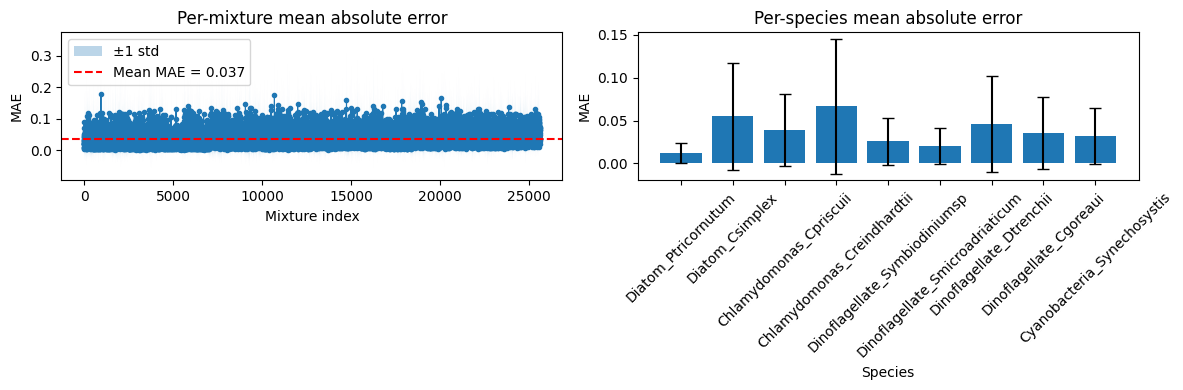

In [57]:
# plot for clarity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mean_accuracy_per_mixture, marker='o', markersize=3, linewidth=0.8)
axes[0].fill_between(
    range(len(mean_accuracy_per_mixture)),
    mean_accuracy_per_mixture - std_accuracy_per_mixture,
    mean_accuracy_per_mixture + std_accuracy_per_mixture,
    alpha=0.3, label='±1 std'
)
axes[0].axhline(np.mean(mean_accuracy_per_mixture), color='red', linestyle='--', label=f'Mean MAE = {np.mean(mean_accuracy_per_mixture):.3f}')
axes[0].set_xlabel("Mixture index")
axes[0].set_ylabel("MAE")
axes[0].set_title("Per-mixture mean absolute error")
axes[0].legend()


species_names = df.columns[1:].tolist()

# mean and std of difference per specie (most insightful)
per_species_mae = np.mean(difference, axis=0)
per_species_std = np.std(difference, axis=0)

axes[1].bar(species_names, per_species_mae, yerr=per_species_std, capsize=4)
axes[1].set_xlabel("Species")
axes[1].set_ylabel("MAE")
axes[1].set_title("Per-species mean absolute error")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [58]:
print(estimated_conc.shape)
print(weights.shape)

(25600, 9)
(25600, 9)


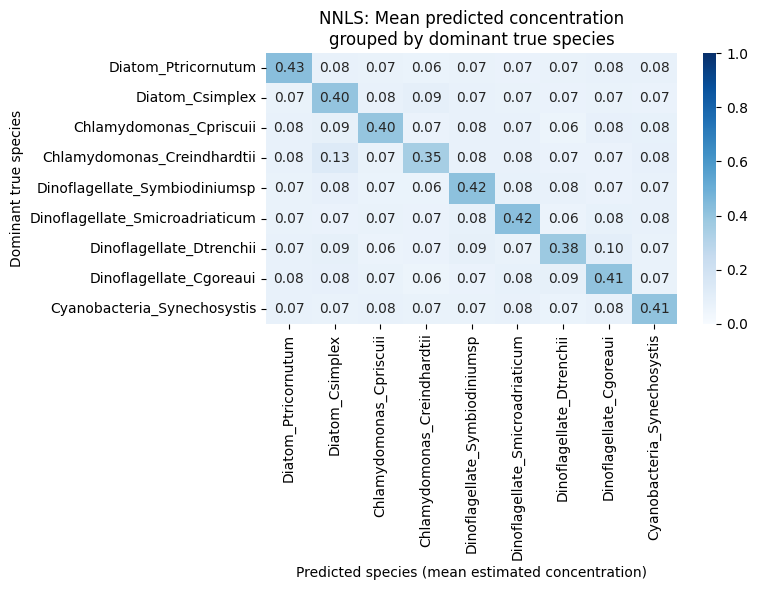

In [59]:
# ground_truth shape: (4600, 9), estimated_conc shape: (4600, 9)
# Identify dominant species per mixture (highest true weight)
dominant_species = np.argmax(weights, axis=1)  # (4600,)

n_species = weights.shape[1]
heatmap = np.zeros((n_species, n_species))
species_names = df.columns[1:].tolist()

for i in range(n_species):
    # Select all mixtures where species i is dominant
    mask = dominant_species == i
    if mask.sum() > 0:
        # Average predicted concentration of each species j in those mixtures
        heatmap[i, :] = estimated_conc[mask].mean(axis=0)

# Optional: normalize each row so values sum to 1
heatmap_norm = heatmap / heatmap.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=species_names,
    yticklabels=species_names,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel("Predicted species (mean estimated concentration)")
ax.set_ylabel("Dominant true species")
ax.set_title("NNLS: Mean predicted concentration\ngrouped by dominant true species")
plt.tight_layout()
plt.show()
# this does not show how the model performs. This plot picks dominant species. Dominant species can have weights of .31, so the spectra is still dominated by the other species! 
# That's why this does not show high diagonal values. To fix this, use a mask with a threshold for the weights -- only dominant species with weights > .6-.8 will show. 


Sample counts per species at different thresholds:
  thresh=0.4: [1545 1479 1387 1509 1503 1484 1494 1421 1465] (total=13287)
  thresh=0.5: [714 665 674 673 680 710 669 647 668] (total=6100)
  thresh=0.6: [265 239 244 248 261 262 248 258 255] (total=2280)
  thresh=0.7: [77 74 73 68 62 79 82 71 71] (total=657)
[[0.32092953 0.31184992 0.31833354 0.03734878 0.01153823 0.
  0.         0.         0.        ]
 [0.20423268 0.19822942 0.43925151 0.01114814 0.14713825 0.
  0.         0.         0.        ]
 [0.01562034 0.24150786 0.38394867 0.08579992 0.2731232  0.
  0.         0.         0.        ]
 [0.0820249  0.04884865 0.16812119 0.48071285 0.22029241 0.
  0.         0.         0.        ]
 [0.24026011 0.04306324 0.35401308 0.23635009 0.12631348 0.
  0.         0.         0.        ]]


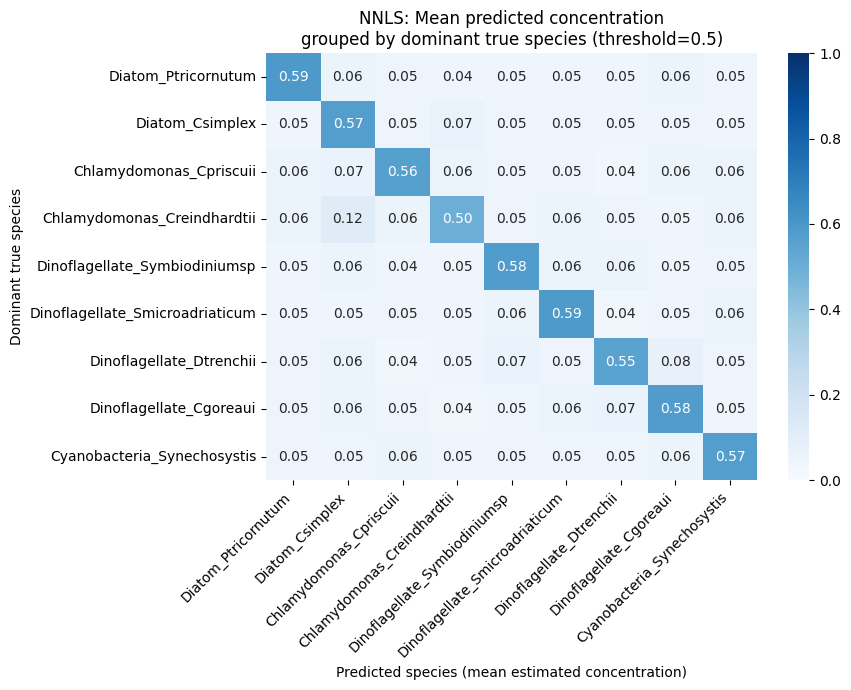

In [60]:
threshold = 0.5  # adjust as needed

# Print sample counts per species at each threshold
print("Sample counts per species at different thresholds:")
for thresh in [0.4, 0.5, 0.6, 0.7]:
    mask = weights.max(axis=1) > thresh
    counts = np.bincount(np.argmax(weights[mask], axis=1), minlength=9)
    print(f"  thresh={thresh}: {counts} (total={mask.sum()})")
print(weights[:5])
# Apply threshold: only keep mixtures where dominant species > threshold
mask_dominant = weights.max(axis=1) > threshold
gt_filtered   = weights[mask_dominant]
ec_filtered   = estimated_conc[mask_dominant]

dominant_species = np.argmax(gt_filtered, axis=1)

n_species = weights.shape[1]
heatmap = np.zeros((n_species, n_species))

for i in range(n_species):
    mask = dominant_species == i
    if mask.sum() > 0:
        heatmap[i, :] = ec_filtered[mask].mean(axis=0)

# Normalize rows to sum to 1
heatmap_norm = heatmap / heatmap.sum(axis=1, keepdims=True)

species_names = [
    "Diatom_Ptricornutum", "Diatom_Csimplex", "Chlamydomonas_Cpriscuii",
    "Chlamydomonas_Creindhardtii", "Dinoflagellate_Symbiodiniumsp",
    "Dinoflagellate_Smicroadriaticum", "Dinoflagellate_Dtrenchii",
    "Dinoflagellate_Cgoreaui", "Cyanobacteria_Synechosystis"
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=species_names,
    yticklabels=species_names,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel("Predicted species (mean estimated concentration)")
ax.set_ylabel("Dominant true species")
ax.set_title(f"NNLS: Mean predicted concentration\ngrouped by dominant true species (threshold={threshold})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# contuining from last comment, this works waaay better!

[0.9871682392266496, 0.6728552249643305, 0.8419942988284808, 0.4995678158847343, 0.9329084876412046, 0.9593296470563756, 0.7542707470837461, 0.8572613252219208, 0.902329623001499]


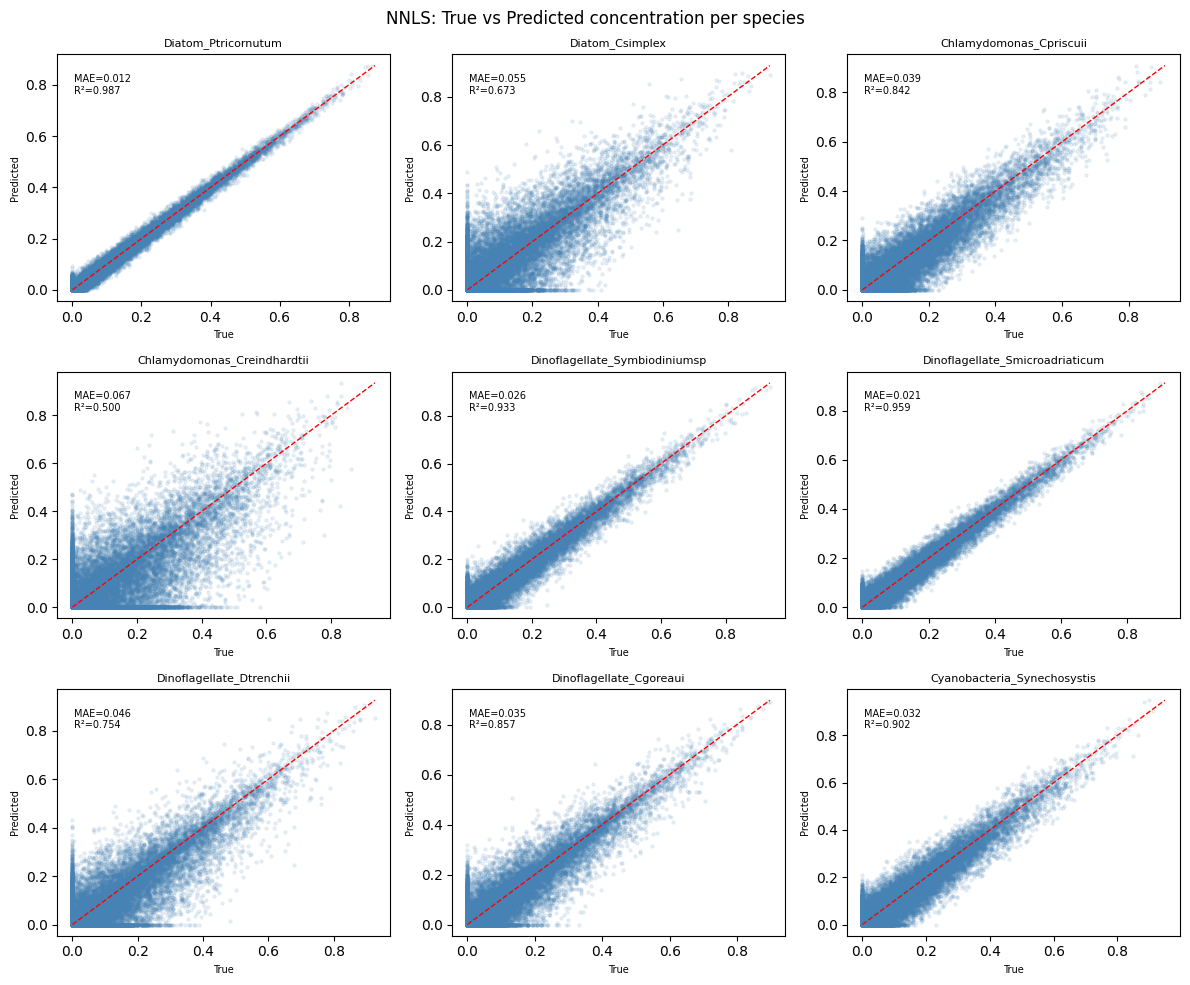

In [61]:
n_species = len(species_names)
ground_truth = weights
# --- Per-species metrics ---
mae_per_species = [mean_absolute_error(ground_truth[:, i], estimated_conc[:, i]) for i in range(n_species)]
r2_per_species  = [r2_score(ground_truth[:, i], estimated_conc[:, i]) for i in range(n_species)]

# --- Scatter plots: true vs predicted per species ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
print(r2_per_species)
for i, (name, ax) in enumerate(zip(species_names, axes)):
    ax.scatter(ground_truth[:, i], estimated_conc[:, i], alpha=0.1, s=5, color="steelblue")
    # Perfect prediction line
    lim = [0, max(ground_truth[:, i].max(), estimated_conc[:, i].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("True", fontsize=7)
    ax.set_ylabel("Predicted", fontsize=7)
    ax.text(0.05, 0.92, f"MAE={mae_per_species[i]:.3f}\nR²={r2_per_species[i]:.3f}",
            transform=ax.transAxes, fontsize=7, verticalalignment='top')

plt.suptitle("NNLS: True vs Predicted concentration per species", fontsize=12)
plt.tight_layout()
plt.show()
# shows predicted concentration values on y-axis versus the true concentration on x-axis. If it is perfect, it should follow the red line (linear). 
# R^2 determines how well the linear fit is. For noise_level = 0, it is perfect!